In [1]:
#!/usr/bin/env python3

import functools
import json
import subprocess
import sys

import tqdm

from archr.targets import DockerImageTarget  # type: ignore
from archr.analyzers import QEMUTracerAnalyzer  # type: ignore
from archr.analyzers.qemu_tracer import QEMUBBLTrace  # type: ignore


In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
def single_trace(image_id: str, full_test_input):
    with DockerImageTarget(image_id).build().start() as target:
        tracer: QEMUTracerAnalyzer = QEMUTracerAnalyzer(target)
        tracer.nock()
        for prefix in tqdm.tqdm([full_test_input], desc="Executing test_inputs"):
            fire_result: QEMUBBLTrace = tracer.fire(testcase=prefix).trace
            block_trace: list[int] = [fire_result[i] for i in range(len(fire_result))]
    return block_trace

def trace_block(image_id: str, labelled_test_inputs: list[tuple[str, bytes]],
                      full_bcov=[]):
    labels, test_inputs = map(list, zip(*labelled_test_inputs))

    block_sets:list[set[int]] = []

    with DockerImageTarget(image_id).build().start() as target:
        tracer: QEMUTracerAnalyzer = QEMUTracerAnalyzer(target)
        tracer.nock()
        for prefix in tqdm.tqdm(test_inputs, desc="Executing test_inputs"):
            fire_result: QEMUBBLTrace = tracer.fire(testcase=prefix).trace
            block_trace: list[int] = [fire_result[i] for i in range(len(fire_result))]
            #edge_sets.append(set(zip(block_trace, block_trace[1:])))
            block_sets.append(set(block_trace))

    blocks_seen = set()
    labelled_blocks: set[int] = set()
    prefix_covs: list[set[int]] = []

    for i, (block_set, prefix, label) in enumerate(zip(block_sets, test_inputs, labels)):
        prefix_covs.append(set())
        if len(prefix) > 0:
            #for block in functools.reduce(set.__and__, block_sets[i:]) - blocks_seen:
            #    # - This is the first time we've seen this block
            #    # - This block appears in all subsequent block sets
            for block in block_sets[i] - blocks_seen:
                # - This is the first time we've seen this block
                # - This block appears in 'last' block sets
                if block in full_bcov:
                    labelled_blocks.add(block)
                    prefix_covs[i].add(block)
            #print(f"idx: {i:3d}, len: {len(test_inputs[i]):5d}, inc: {len(prefix_covs[i]):5d}, input: {test_inputs[i]}")
        blocks_seen |= block_set

    return test_inputs, prefix_covs


def trace_block_counts(test_inputs, prefix_covs):
    len_input = [len(s) for s in test_inputs]
    len_prefix = [0]
    for i in range(1, len(prefix_covs)):
        len_prefix.append(len_prefix[-1] + len(prefix_covs[i]))

    return len_input, len_prefix




RULE_NAMES: list[str] = ["scheme", "user", "password", "host", "port", "path", "query", "frag"]
intermediate_result: str = ""

def walk(pt: dict, result: list[bytes] | None = None, rules: list[str] | None = None, depth: int = 0):
    global intermediate_result
    if result is None:
        result = []
    if rules is None:
        rules = []

    text: str = pt['text'].rstrip("<EOF>")

    if "ruleName" in pt:
        rule_name: str = pt['ruleName']
        if rule_name in RULE_NAMES:
            rules.append(rule_name)
            if len(result) == 0:
                result.append(intermediate_result.encode("latin1"))
            else:
                result.append(result[-1] + intermediate_result.encode("latin1"))

            intermediate_result = ""
    else:
        # Terminal
        intermediate_result += text

    if "children" in pt:
        for child in pt["children"]:
            walk(child, result, rules, depth + 1)

    if depth == 0:
        result.append(text.encode("latin1"))
        return list(zip([""] + rules, result))


def walk_terminals(pt):
    def dfs(node):
        if node["type"] == "terminal":
            return [node["text"].encode("latin1")]
        ret = []
        for child in node["children"]:
            ret += dfs(child)
        return ret
    test_inputs = []
    terminals = dfs(pt)
    for i in range(len(terminals)):
        test_inputs.append((f"terminal_{i}", b"".join(terminals[:i])))
    return test_inputs



def get_naive_prefix(data: bytes):
    prefixes = []
    for i in range(len(data)+1):
        prefixes.append((f"naive_{i}", data[:i]))
    return prefixes



In [3]:

def get_results(pt, docker_image_id):
    terminal_inputs = walk_terminals(pt)
    full_input = terminal_inputs[-1][1]
    naive_inputs = get_naive_prefix(full_input)
    
    single_bcov = single_trace(docker_image_id, full_input)
    
    
    single_bcov = single_trace(docker_image_id, labelled_test_inputs[-1][1])
    
    in_a, cov_a = trace_block(docker_image_id, naive_inputs, single_bcov)
    
    in_b, cov_b = trace_block(docker_image_id, terminal_inputs, single_bcov)

    return *trace_block_counts(in_a, cov_a), *trace_block_counts(in_b, cov_b)


In [39]:
with open("../url-example.json") as f:
    j: dict = json.load(f)
pt: dict = j["parse_tree"]

curl_bb_in, curl_bb_covs, curl_pre_in, curl_pre_covs = get_results(pt, "archr/curl_url")
apr_bb_in, apr_bb_covs, apr_pre_in, ar_pre_covs = get_results(pt, "archr/apr_uri_parse")

/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Executing test_inputs: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.45it/s]
/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.p

/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Executing test_inputs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:08<00:00,  4.41it/s]


/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Executing test_inputs: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:02<00:00,  3.88it/s]
/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.p

/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Executing test_inputs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:10<00:00,  3.80it/s]


/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/weicheng/.pyenv/versions/sure25/lib/python3.13/site-packages/shellphish_qemu/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Executing test_inputs: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:02<00:00,  3.70it/s]


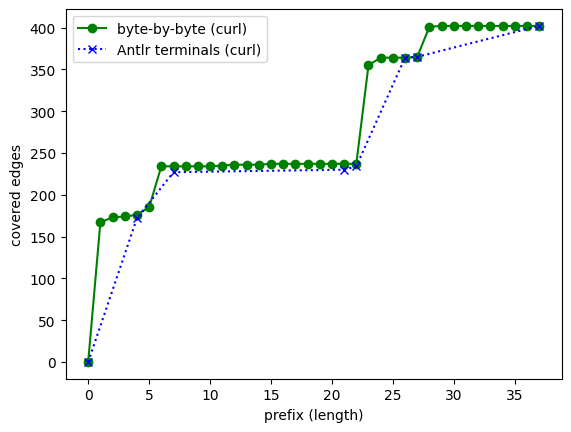

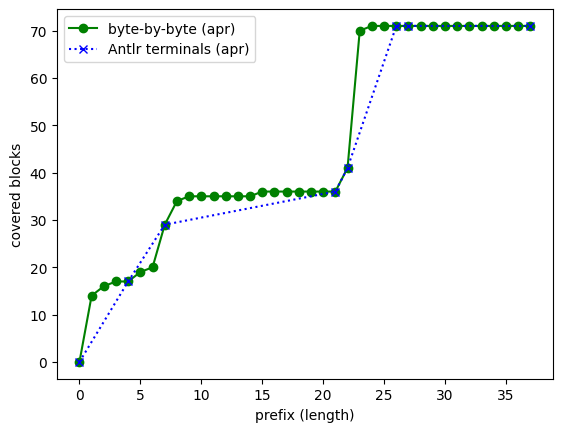

In [45]:
plt.plot(curl_bb_in, curl_bb_covs, label='byte-by-byte (curl)', marker='o', color="green" , linestyle='solid')
plt.plot(curl_pre_in, curl_pre_covs, label='Antlr tokens (curl)', marker='x', color="blue", linestyle='dotted')

plt.xlabel("prefix (length)")
plt.ylabel("covered edges")
plt.legend()
plt.show()

#plt.plot(apr_bb_in, apr_bb_covs, label='byte-by-byte (apr)', marker='o', color="red", linestyle='dashed')
#plt.plot(apr_pre_in, ar_pre_covs, label='Antlr terminals (apr)', marker='o', color="purple", linestyle='dashdot')
plt.plot(apr_bb_in, apr_bb_covs, label='byte-by-byte (apr)', marker='o', color="green" , linestyle='solid')
plt.plot(apr_pre_in, ar_pre_covs, label='Antlr tokens (apr)', marker='x', color="blue", linestyle='dotted')

plt.xlabel("prefix (length)")
plt.ylabel("covered blocks")
plt.legend()
plt.show()


In [16]:
"""
json
"""
with open("exp/json-example1.json", "r") as fd:
    data = json.load(fd)

def acum_prefix(prefix_covs):
    len_prefix = [0]
    for i in range(1, len(prefix_covs)):
        len_prefix.append(len_prefix[-1] + len(prefix_covs[i]))

    return len_prefix

json_bb_in = [i for i in range(len(data["results"][0]["byte_covs"]))]
json_bb_covs = acum_prefix(data["results"][0]["byte_covs"])
json_pre_covs = acum_prefix(data["results"][0]["prefix_covs"])
json_pre_in = [len(s) for s in data["parsed_tokens"]]

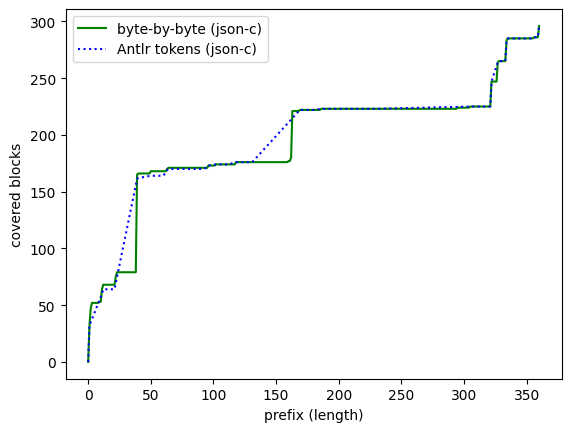

In [19]:

plt.plot(json_bb_in, json_bb_covs, label='byte-by-byte (json-c)', color="green" , linestyle='solid')
plt.plot(json_pre_in, json_pre_covs, label='Antlr tokens (json-c)', color="blue", linestyle='dotted')

plt.xlabel("prefix (length)")
plt.ylabel("covered blocks")
plt.legend()
plt.show()


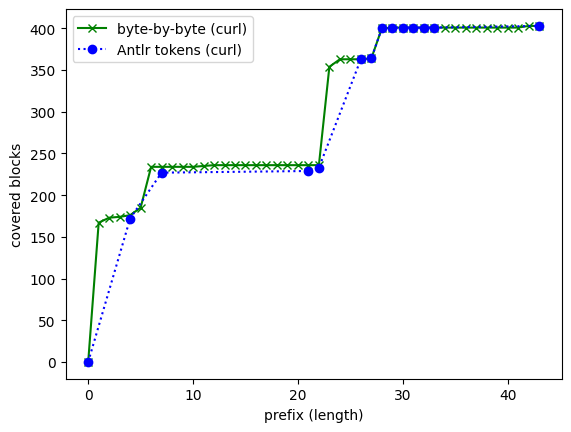

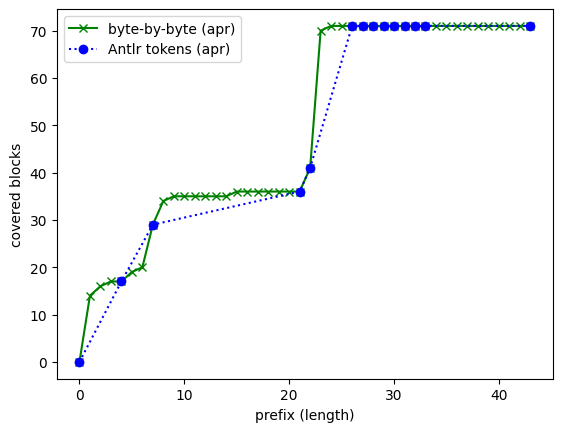

In [24]:
"""
url
"""
with open("exp/url/data/example3.json", "r") as fd:
    data = json.load(fd)

def acum_prefix(prefix_covs):
    len_prefix = [0]
    for i in range(1, len(prefix_covs)):
        len_prefix.append(len_prefix[-1] + len(prefix_covs[i]))

    return len_prefix
    
for idx in range(2):
    if idx == 0:
        name = "curl"
    else:
        name = "apr"
    bb_in = [i for i in range(len(data["results"][idx]["byte_covs"]))]
    bb_covs = acum_prefix(data["results"][idx]["byte_covs"])
    pre_covs = acum_prefix(data["results"][idx]["prefix_covs"])
    pre_in = [len(s) for s in data["parsed_tokens"]]
    
    plt.plot(bb_in, bb_covs, label=f"byte-by-byte ({name})", marker='x', color="green" , linestyle='solid')
    plt.plot(pre_in, pre_covs, label=f"Antlr tokens ({name})", marker='o', color="blue", linestyle='dotted')
    
    plt.xlabel("prefix (length)")
    plt.ylabel("covered blocks")
    plt.legend()
    plt.show()


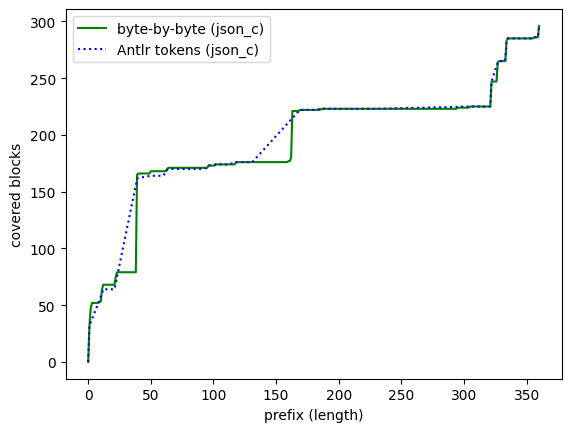

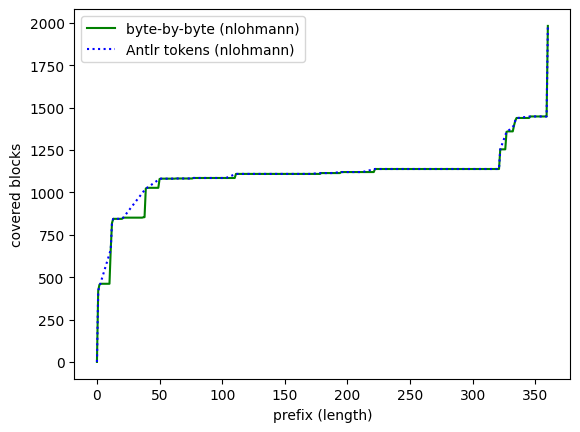

In [26]:
"""
json
"""
with open("exp/json/data/example1.json", "r") as fd:
    data = json.load(fd)

def acum_prefix(prefix_covs):
    len_prefix = [0]
    for i in range(1, len(prefix_covs)):
        len_prefix.append(len_prefix[-1] + len(prefix_covs[i]))

    return len_prefix
    
for idx in range(2):
    if idx == 0:
        name = "json_c"
    else:
        name = "nlohmann"
    bb_in = [i for i in range(len(data["results"][idx]["byte_covs"]))]
    bb_covs = acum_prefix(data["results"][idx]["byte_covs"])
    pre_covs = acum_prefix(data["results"][idx]["prefix_covs"])
    pre_in = [len(s) for s in data["parsed_tokens"]]
    
    plt.plot(bb_in, bb_covs, label=f"byte-by-byte ({name})", color="green" , linestyle='solid')
    plt.plot(pre_in, pre_covs, label=f"Antlr tokens ({name})", color="blue", linestyle='dotted')
    
    plt.xlabel("prefix (length)")
    plt.ylabel("covered blocks")
    plt.legend()
    plt.show()


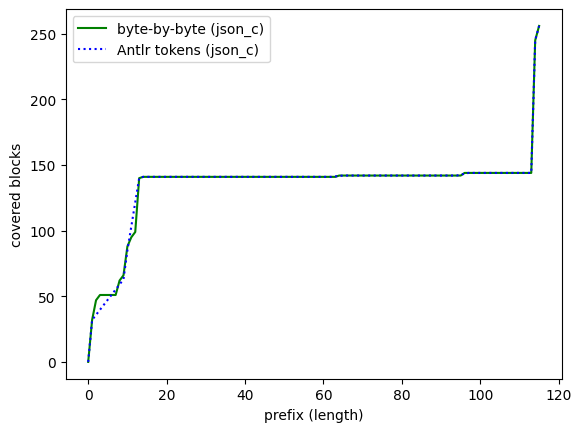

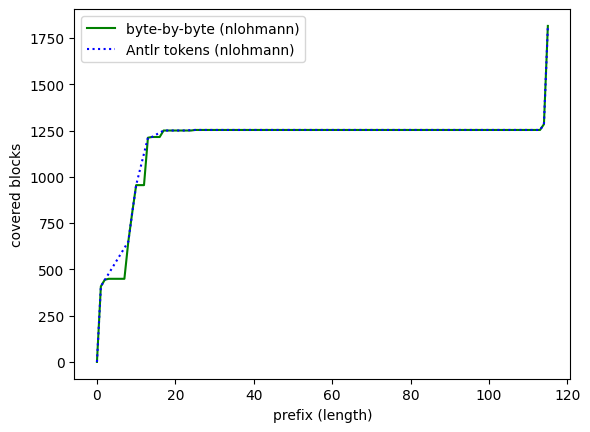

In [27]:
"""
json - repeated
"""
with open("exp/json/data/repeat.json", "r") as fd:
    data = json.load(fd)

def acum_prefix(prefix_covs):
    len_prefix = [0]
    for i in range(1, len(prefix_covs)):
        len_prefix.append(len_prefix[-1] + len(prefix_covs[i]))

    return len_prefix
    
for idx in range(2):
    if idx == 0:
        name = "json_c"
    else:
        name = "nlohmann"
    bb_in = [i for i in range(len(data["results"][idx]["byte_covs"]))]
    bb_covs = acum_prefix(data["results"][idx]["byte_covs"])
    pre_covs = acum_prefix(data["results"][idx]["prefix_covs"])
    pre_in = [len(s) for s in data["parsed_tokens"]]
    
    plt.plot(bb_in, bb_covs, label=f"byte-by-byte ({name})", color="green" , linestyle='solid')
    plt.plot(pre_in, pre_covs, label=f"Antlr tokens ({name})", color="blue", linestyle='dotted')
    
    plt.xlabel("prefix (length)")
    plt.ylabel("covered blocks")
    plt.legend()
    plt.show()


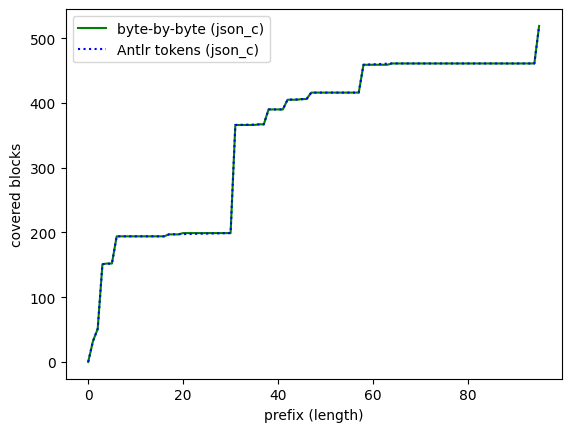

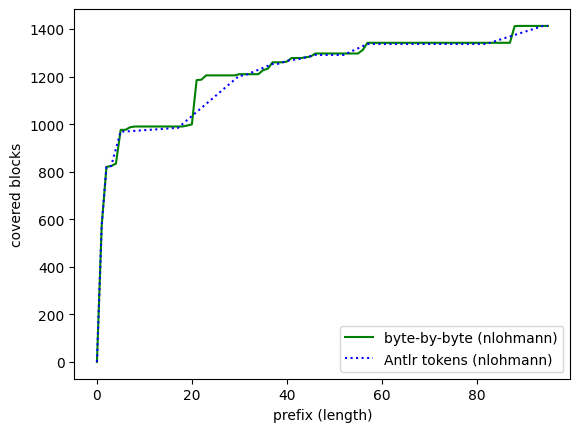

In [28]:
"""
json - numbers
"""
with open("exp/json/data/numbers.json", "r") as fd:
    data = json.load(fd)

def acum_prefix(prefix_covs):
    len_prefix = [0]
    for i in range(1, len(prefix_covs)):
        len_prefix.append(len_prefix[-1] + len(prefix_covs[i]))

    return len_prefix
    
for idx in range(2):
    if idx == 0:
        name = "json_c"
    else:
        name = "nlohmann"
    bb_in = [i for i in range(len(data["results"][idx]["byte_covs"]))]
    bb_covs = acum_prefix(data["results"][idx]["byte_covs"])
    pre_covs = acum_prefix(data["results"][idx]["prefix_covs"])
    pre_in = [len(s) for s in data["parsed_tokens"]]
    
    plt.plot(bb_in, bb_covs, label=f"byte-by-byte ({name})", color="green" , linestyle='solid')
    plt.plot(pre_in, pre_covs, label=f"Antlr tokens ({name})", color="blue", linestyle='dotted')
    
    plt.xlabel("prefix (length)")
    plt.ylabel("covered blocks")
    plt.legend()
    plt.show()
